In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("Supply chain logisitcs problem.xlsx")

# Show basic info
print(df.head())
print(df.info())

# Handle missing values
df = df.dropna()

# Convert categorical to numeric
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("Data after cleaning:")
print(df.head())

       Order ID Order Date Origin Port Carrier  TPT Service Level  \
0  1.447296e+09 2013-05-26      PORT09   V44_3    1           CRF   
1  1.447158e+09 2013-05-26      PORT09   V44_3    1           CRF   
2  1.447139e+09 2013-05-26      PORT09   V44_3    1           CRF   
3  1.447364e+09 2013-05-26      PORT09   V44_3    1           CRF   
4  1.447364e+09 2013-05-26      PORT09   V44_3    1           CRF   

   Ship ahead day count  Ship Late Day count   Customer  Product ID  \
0                     3                    0  V55555_53     1700106   
1                     3                    0  V55555_53     1700106   
2                     3                    0  V55555_53     1700106   
3                     3                    0  V55555_53     1700106   
4                     3                    0  V55555_53     1700106   

  Plant Code Destination Port  Unit quantity  Weight  
0    PLANT16           PORT09            808   14.30  
1    PLANT16           PORT09           3188   8

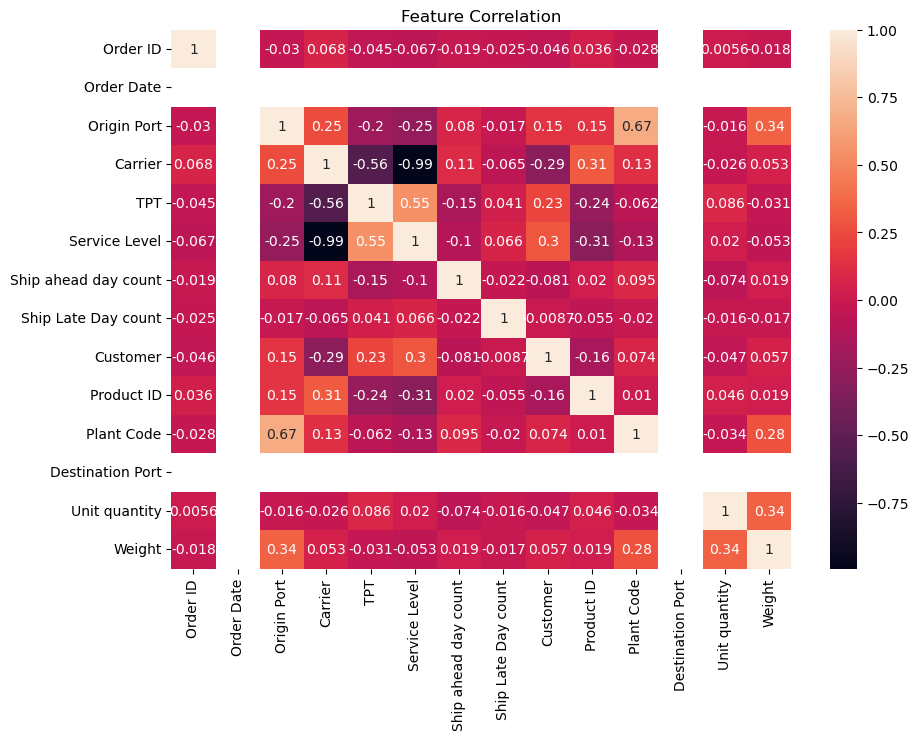

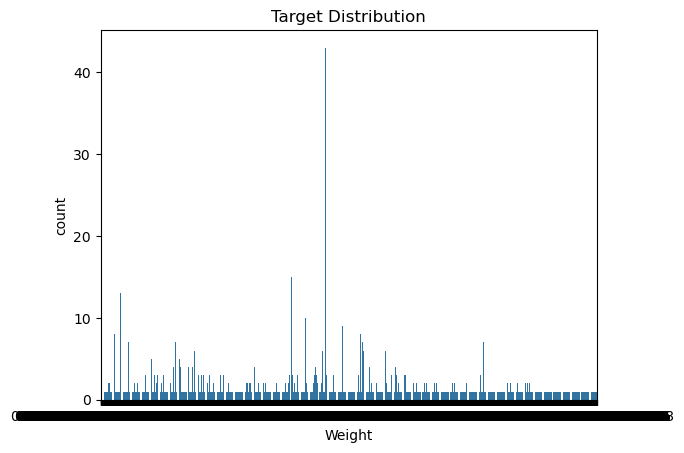

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

# Distribution of target
target_col = df.columns[-1]

sns.countplot(x=df[target_col])
plt.title("Target Distribution")
plt.show()

In [4]:
# STEP 1: Define X and y FIRST
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# STEP 2: Handle datetime
for col in X.select_dtypes(include=['datetime64[ns]']).columns:
    X[col + "_year"] = X[col].dt.year
    X[col + "_month"] = X[col].dt.month
    X[col + "_day"] = X[col].dt.day
    X[col + "_dayofweek"] = X[col].dt.dayofweek

# Drop original datetime columns
X = X.drop(columns=X.select_dtypes(include=['datetime64[ns]']).columns)

# STEP 3: Encode categorical
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# STEP 4: Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

In [6]:
from sklearn.model_selection import train_test_split

y = df.iloc[:, -1]
X = df.iloc[:, :-1]

# Apply preprocessing BEFORE split
# (important fix)

In [15]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Handle datetime
for col in X.select_dtypes(include=['datetime64[ns]']).columns:
    X[col + "_year"] = X[col].dt.year
    X[col + "_month"] = X[col].dt.month
    X[col + "_day"] = X[col].dt.day
    X[col + "_dayofweek"] = X[col].dt.dayofweek

X = X.drop(columns=X.select_dtypes(include=['datetime64[ns]']).columns)

# Encode categorical
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Now split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8945970073199292


In [9]:
from sklearn.metrics import confusion_matrix

# convert continuous → binary
y_test_bin = (y_test > y_test.median()).astype(int)
y_pred_bin = (y_pred > y_test.median()).astype(int)

cm = confusion_matrix(y_test_bin, y_pred_bin)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[773 149]
 [ 65 856]]


In [10]:
import numpy as np

print("Mean of features:\n", np.mean(X, axis=0))
print("Std deviation:\n", np.std(X, axis=0))

Mean of features:
 Order ID                  1447273698.881769
Order Date              2013-05-26 00:00:00
Origin Port                        0.037656
Carrier                            0.412914
TPT                                1.717743
Service Level                      1.582094
Ship ahead day count               1.852306
Ship Late Day count                0.039935
Customer                          21.261747
Product ID                   1680536.058709
Plant Code                         0.315681
Destination Port                        0.0
Unit quantity                   3202.747151
dtype: object
Std deviation:
 Order ID                   83811.744848
Order Date              0 days 00:00:00
Origin Port                    0.271635
Carrier                        0.654038
TPT                            0.630466
Service Level                  0.654683
Ship ahead day count           1.922198
Ship Late Day count            0.319608
Customer                       11.03163
Product ID         

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: 0.2727531863745406


In [16]:
# 🔧 REMOVE datetime before scaling
for col in X.select_dtypes(include=['datetime64[ns]']):
    X[col+"_year"] = X[col].dt.year
    X[col+"_month"] = X[col].dt.month
    X[col+"_day"] = X[col].dt.day

# drop original datetime columns
X = X.drop(columns=X.select_dtypes(include=['datetime64[ns]']).columns)

# ensure all numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# ✅ NOW scaling will work
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)

# sample prediction
new_data = X.iloc[[0]]
new_data_scaled = scaler.transform(new_data)

prediction = rf.predict(new_data_scaled)

print("Prediction:", prediction)

Prediction: [639.54128825]


c:\Users\kesha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
